In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


In [57]:
df=pd.read_csv('mnist_test.csv')

In [58]:

df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [60]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
X = df.drop('label', axis=1)
y = df['label']


In [62]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


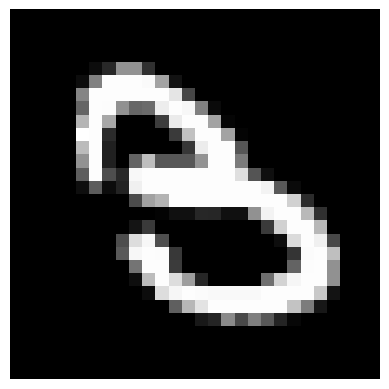

In [63]:
img = X[df['label'] ==3 ].iloc[0].values
plt.imshow(img.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()


In [64]:
X.shape   # (n_samples, 784)
y.unique()


array([7, 2, 1, 0, 4, 9, 5, 6, 3, 8])

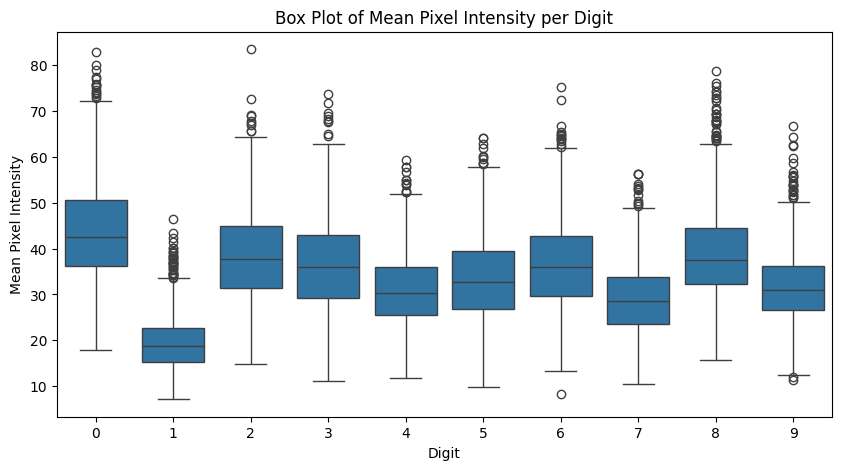

In [74]:
import pandas as pd
import seaborn as sns

# Compute mean pixel intensity per image
mean_pixel_intensity = X.mean(axis=1)

box_df = pd.DataFrame({
    "Digit": y,
    "Mean Pixel Intensity": mean_pixel_intensity
})

plt.figure(figsize=(10,5))
sns.boxplot(
    x="Digit",
    y="Mean Pixel Intensity",
    data=box_df
)
plt.title("Box Plot of Mean Pixel Intensity per Digit")
plt.show()


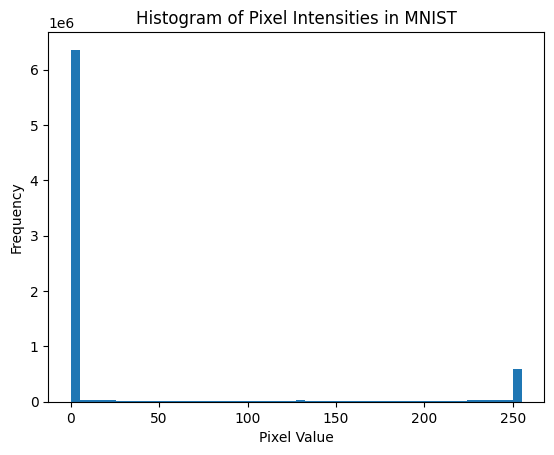

In [73]:
import matplotlib.pyplot as plt

# Histogram of all pixel values
plt.hist(X.values.flatten(), bins=50)
plt.title("Histogram of Pixel Intensities in MNIST")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


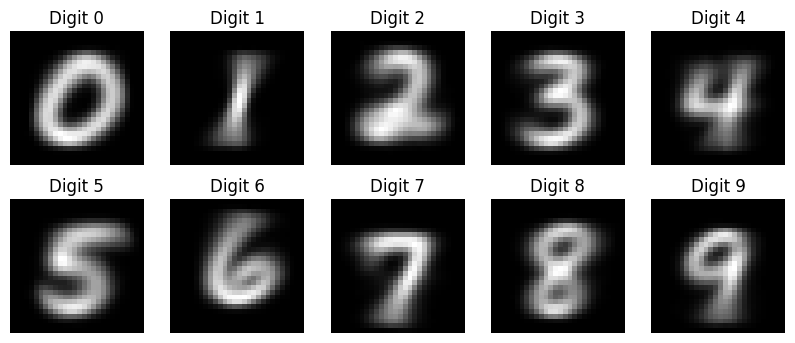

In [67]:
plt.figure(figsize=(10,4))
for digit in range(10):
    mean_img = X[y == digit].mean().values.reshape(28,28)
    plt.subplot(2,5,digit+1)
    plt.imshow(mean_img, cmap="gray")
    plt.title(f"Digit {digit}")
    plt.axis("off")
plt.show()


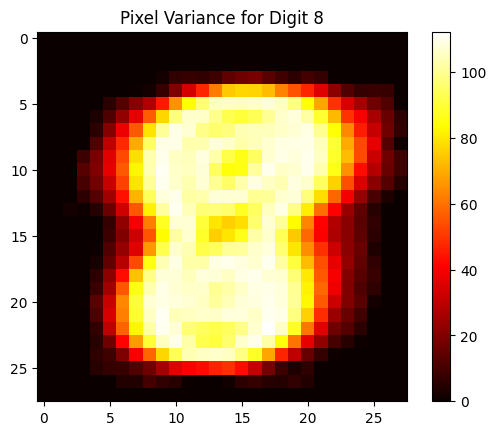

In [68]:
std_img = X[y == 8].std().values.reshape(28,28)
plt.imshow(std_img, cmap="hot")
plt.title("Pixel Variance for Digit 8")
plt.colorbar()
plt.show()


In [69]:
X = df.iloc[:, 1:]   # 784 pixel columns
y = df.iloc[:, 0]    # label column


In [70]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)


In [71]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["label"] = y


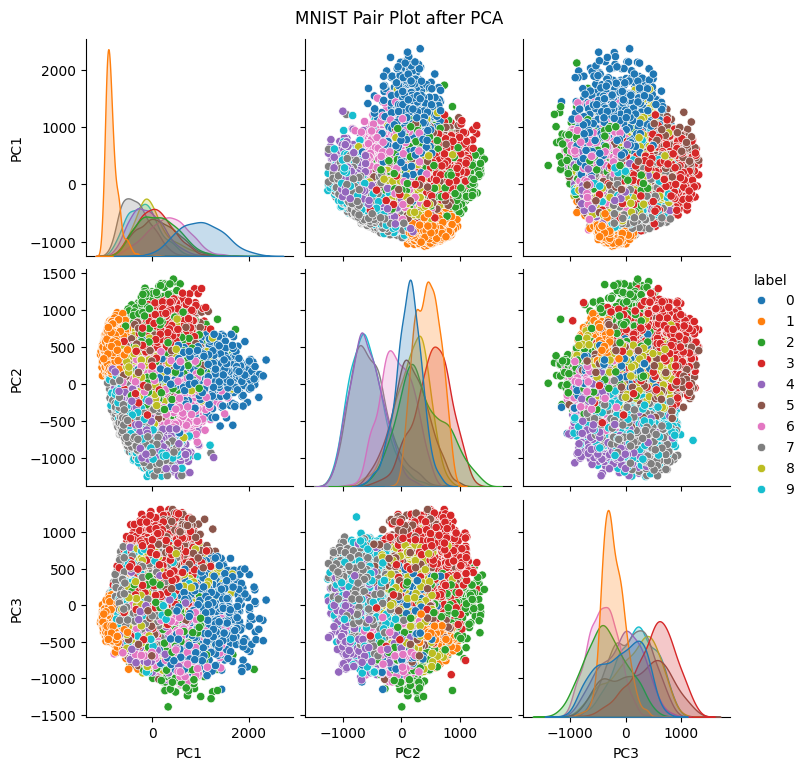

In [72]:
sns.pairplot(
    pca_df,
    vars=["PC1", "PC2", "PC3"],
    hue="label",
    palette="tab10",
    diag_kind="kde"
)

plt.suptitle("MNIST Pair Plot after PCA", y=1.02)
plt.show()


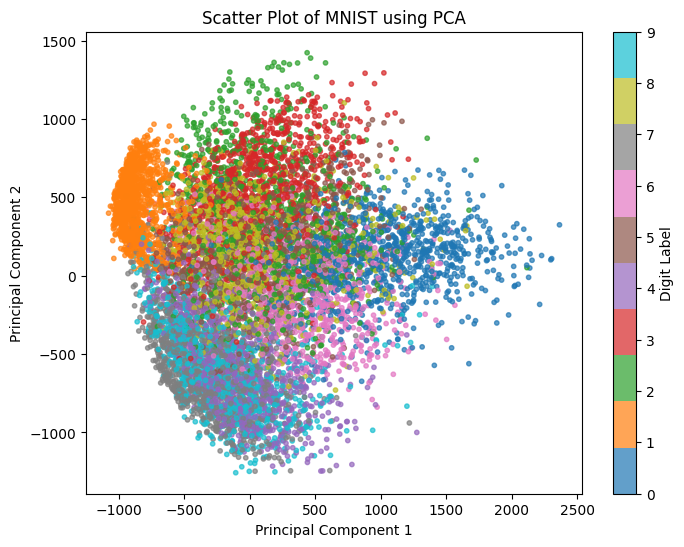

In [75]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot of MNIST using PCA")
plt.colorbar(label="Digit Label")
plt.show()

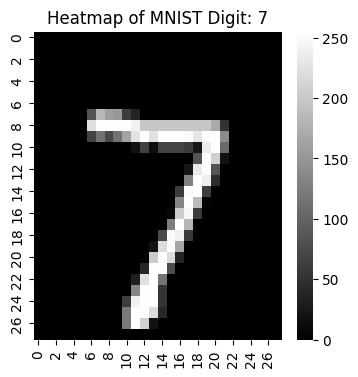

In [78]:
# Select one image
img = X.iloc[0].values.reshape(28, 28)

plt.figure(figsize=(4,4))
sns.heatmap(img, cmap="gray", cbar=True)
plt.title(f"Heatmap of MNIST Digit: {y.iloc[0]}")
plt.show()

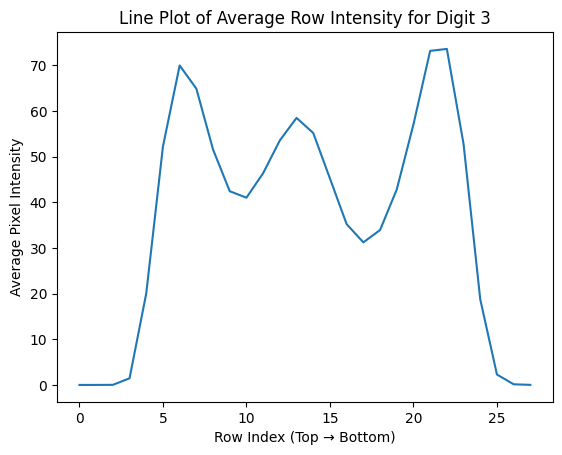

In [79]:
digit = 3
digit_imgs = X[y == digit].values.reshape(-1, 28, 28)

# Average intensity per row
avg_row_intensity = digit_imgs.mean(axis=0).mean(axis=1)

plt.plot(avg_row_intensity)
plt.xlabel("Row Index (Top → Bottom)")
plt.ylabel("Average Pixel Intensity")
plt.title(f"Line Plot of Average Row Intensity for Digit {digit}")
plt.show()